# Basic examples with overview of possibilities

In [ ]:
# -*- coding: utf-8 -*-
"""

Created on 2024.

@author: Ronan Abhervé, Alexandre Gauvain, Jean-Raynald de Dreuzy

"""

# FIRST HYDROMODPY EXAMPLE

In [2]:
#%% ---- LIBRAIRIES

# PYTHON PACKAGES

import sys
import os
import glob
import warnings
warnings.filterwarnings("ignore", message=".*An exception was ignored while fetching the attribute.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*`np.object` is a deprecated alias for the builtin `object`.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated. Use tobytes().*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated since Matplotlib 3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import flopy
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'inline') # %matplotlib notebook, qt
import imageio
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

# ROOT DIRECTORY

from os.path import dirname, abspath
# root_dir = dirname(dirname(dirname(abspath(__file__))))
root_dir = dirname(dirname(os.getcwd()))
sys.path.append(root_dir)
cwd = os.getcwd()
print("Root path directory is: {0}".format(root_dir.upper()))

# HYDROMODPY MODEULES

import src
import importlib
importlib.reload(src)
from src import watershed_root
from src.watershed import climatic, geographic, geology, geometric, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox, folder_root
fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large


Root path directory is: /HOME/AGAUVAIN/GIT/HYDROMODPY


/home/agauvain/anaconda3/envs/hydromodpy/lib/python3.8/site-packages/osgeo/__init__.py:8: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp


In [3]:
#%% ---- PERSONAL PATHS

example_path = os.path.join(root_dir, "examples/00_simplified example presentend in the paper")
data_path = os.path.join(example_path, "data")

#out_path = folder_root.update_root_folder_results()
out_path = os.path.join(root_dir,'examples', 'results')
# Or for example:
# out_path = 'C:/Simulations/HydroModPy/'
print('The results of the example will be saved here :', out_path)


The results of the example will be saved here : /home/agauvain/Git/HydroModPy/examples/results


In [5]:
#%% ---- EXTRACT CATCHMENT

# Name of the study site
watershed_name = 'Example_00_Canut'
print('##### '+watershed_name.upper()+' #####')

# Regional DEM
dem_path = os.path.join(data_path, 'regional dem.tif')

# Outlet coordinates of the catchment
from_xyv = [327816.965, 6777886.670, 150, 10 , 'EPSG:2154']

# Extract the catchment from a regional DEM
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=False,
                              watershed_name=watershed_name,
                              from_lib=None, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=None, # [path, cell size]
                              from_shp=None, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=None, # path 
                              save_object=True)

# Paths necessary for the script
stable_folder = os.path.join(out_path, watershed_name, 'results_stable')
simulations_folder = os.path.join(out_path, watershed_name, 'results_simulations')


##### EXAMPLE_00_CANUT #####
      __  __          __           __  ____          ________     
     / / / /         / /          /  \/   /         / / __  /     
    / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
   / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
  / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
 /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
       /____/ Hydrological Modelling in Python /_____________/    
                                                                  
Object was not loaded as demanded, but created from scratch
Create new object, will removed previousy stored object
Extract geography of the model area
   Reshape tifs


Extract geology from specific data
Extract hydrography from specific data
     MultiLineString
Extract hydrometry from specific data
Extract intermittency from specific data
Extract subbasin from generated and added data


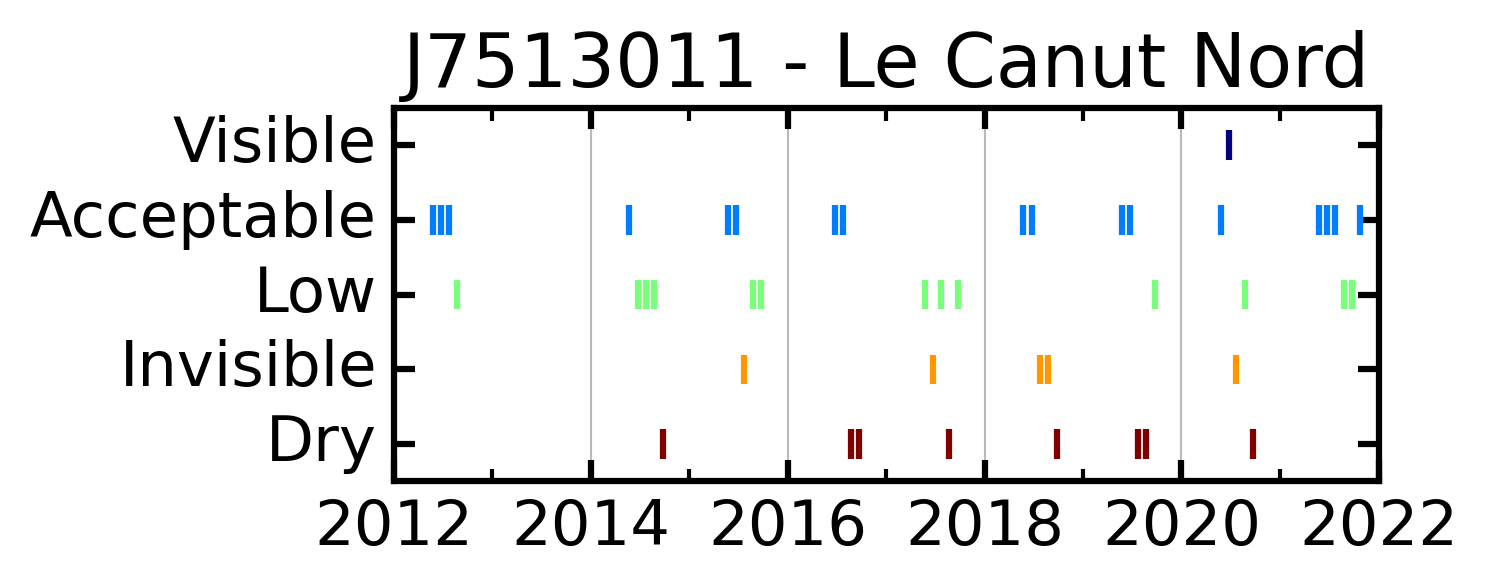

In [6]:
#%% ---- ADD DATA

# Clip specific data at the catchment scale
# BV.add_piezometry() # no piezomoeter for this study site
BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
BV.add_hydrography(data_path, types_obs=['regional stream network'])
BV.add_hydrometry(data_path, 'france hydrometric stations.shp')
BV.add_intermittency(data_path, 'regional onde stations.shp')

# Extract a subbasin inside the study site
BV.add_subbasin(os.path.join(data_path, 'additional'), 150)

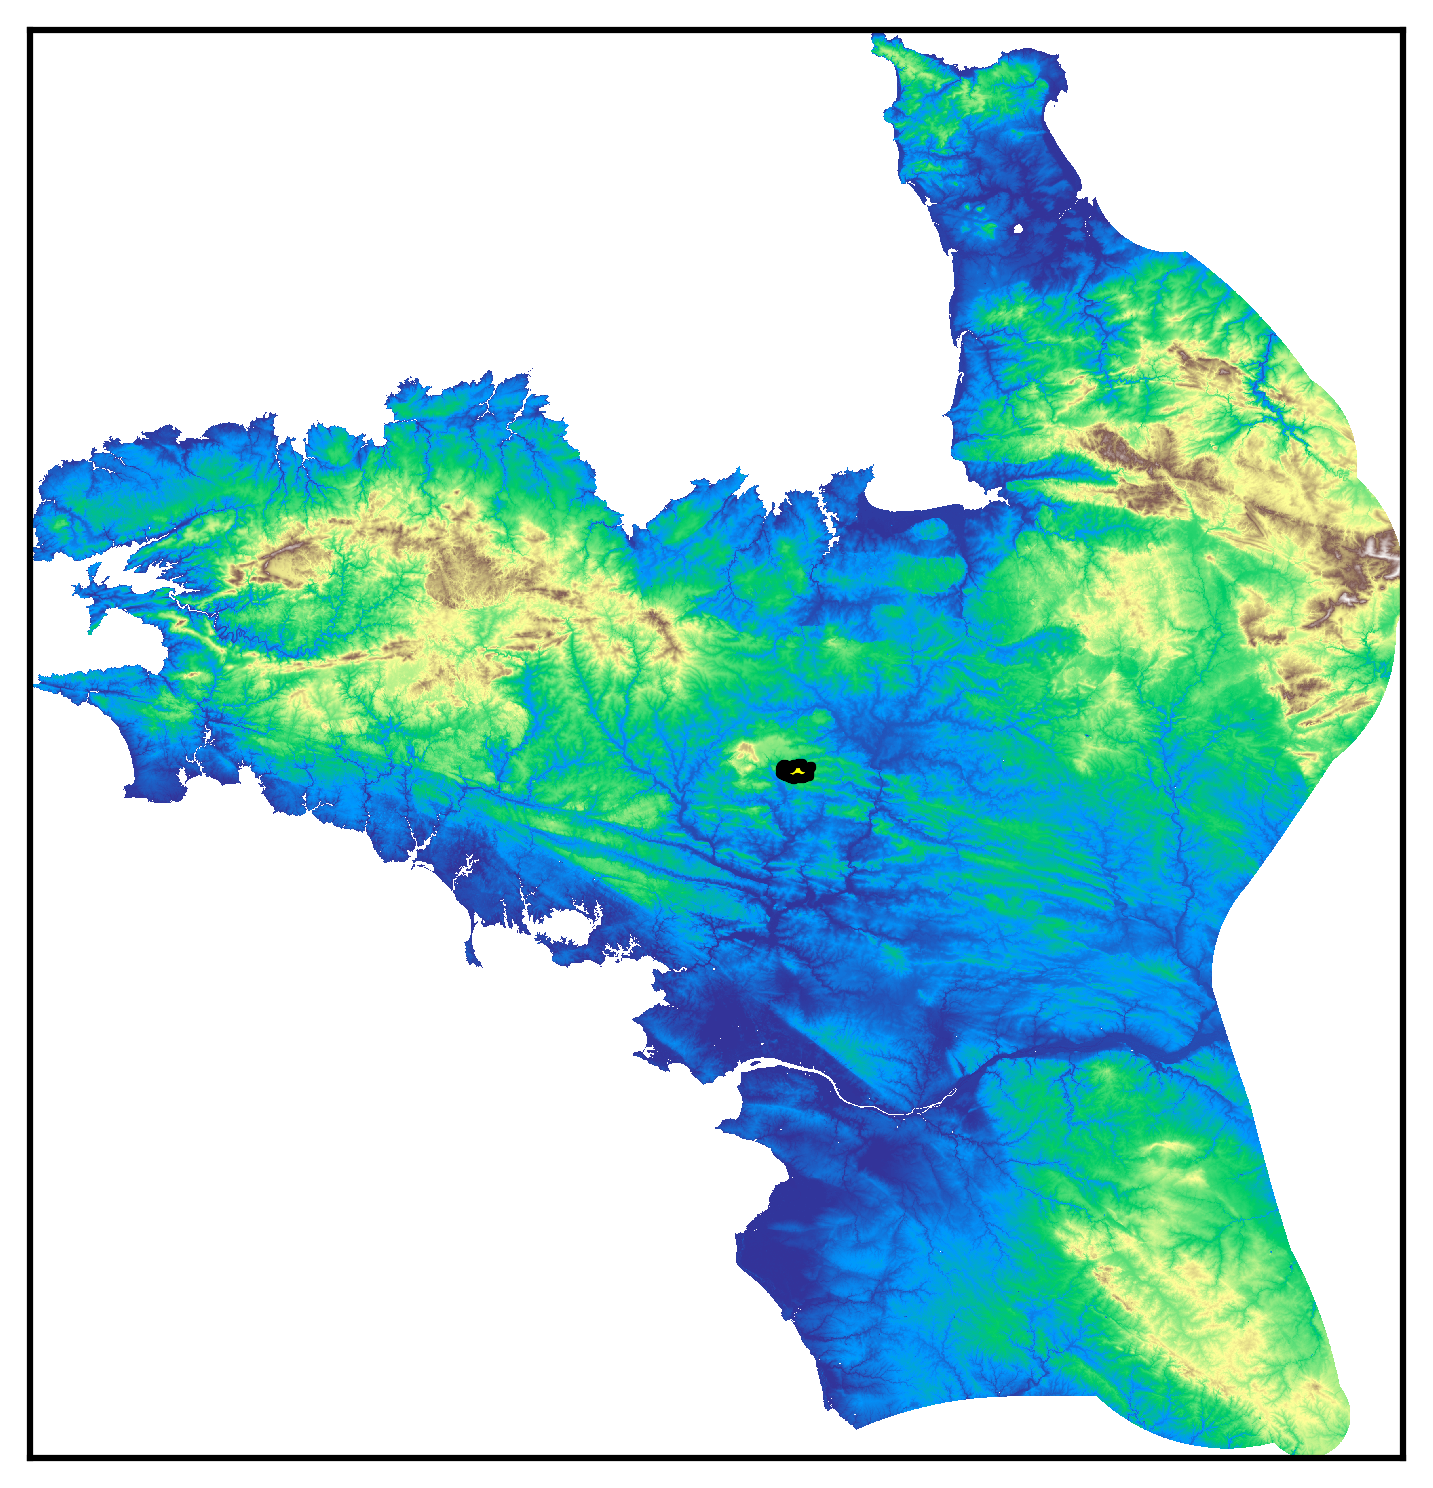

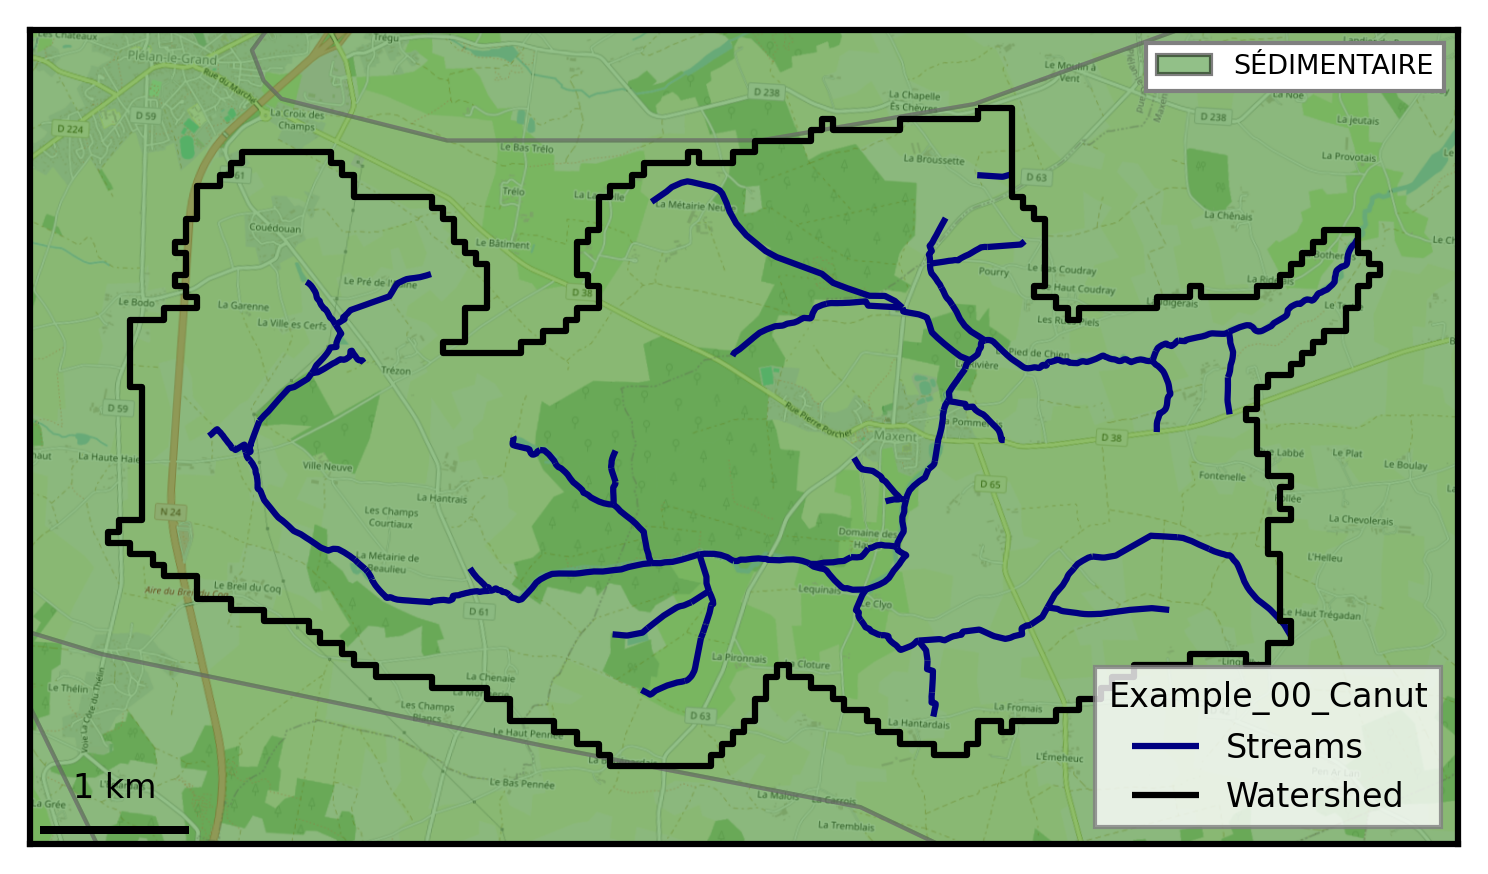

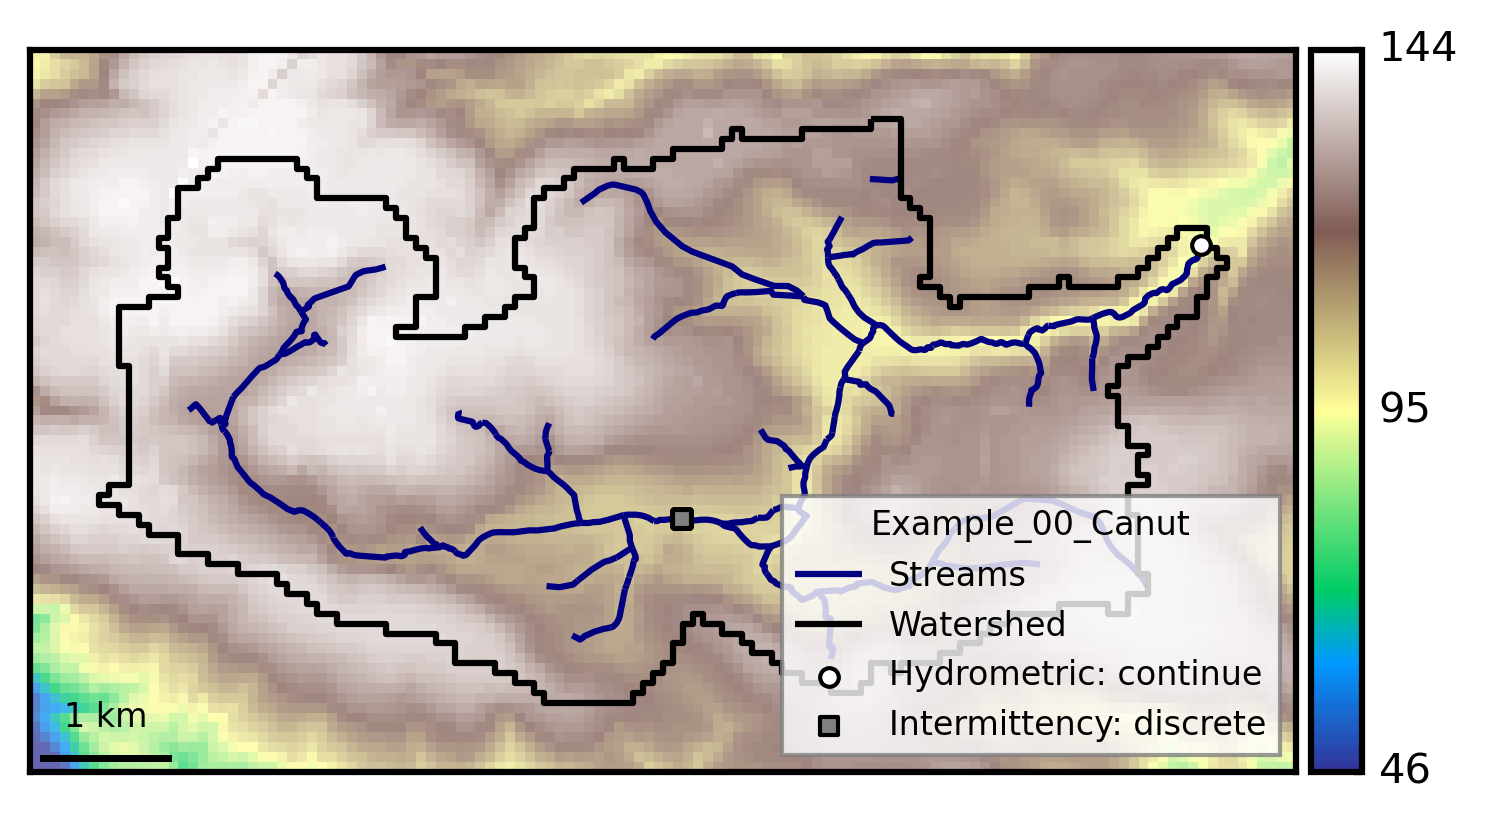

In [8]:
#%% ---- WATERSHED MAP

# General plot of the study site
visualization_watershed.watershed_local(dem_path, BV)
visualization_watershed.watershed_geology(BV)
visualization_watershed.watershed_dem(BV)

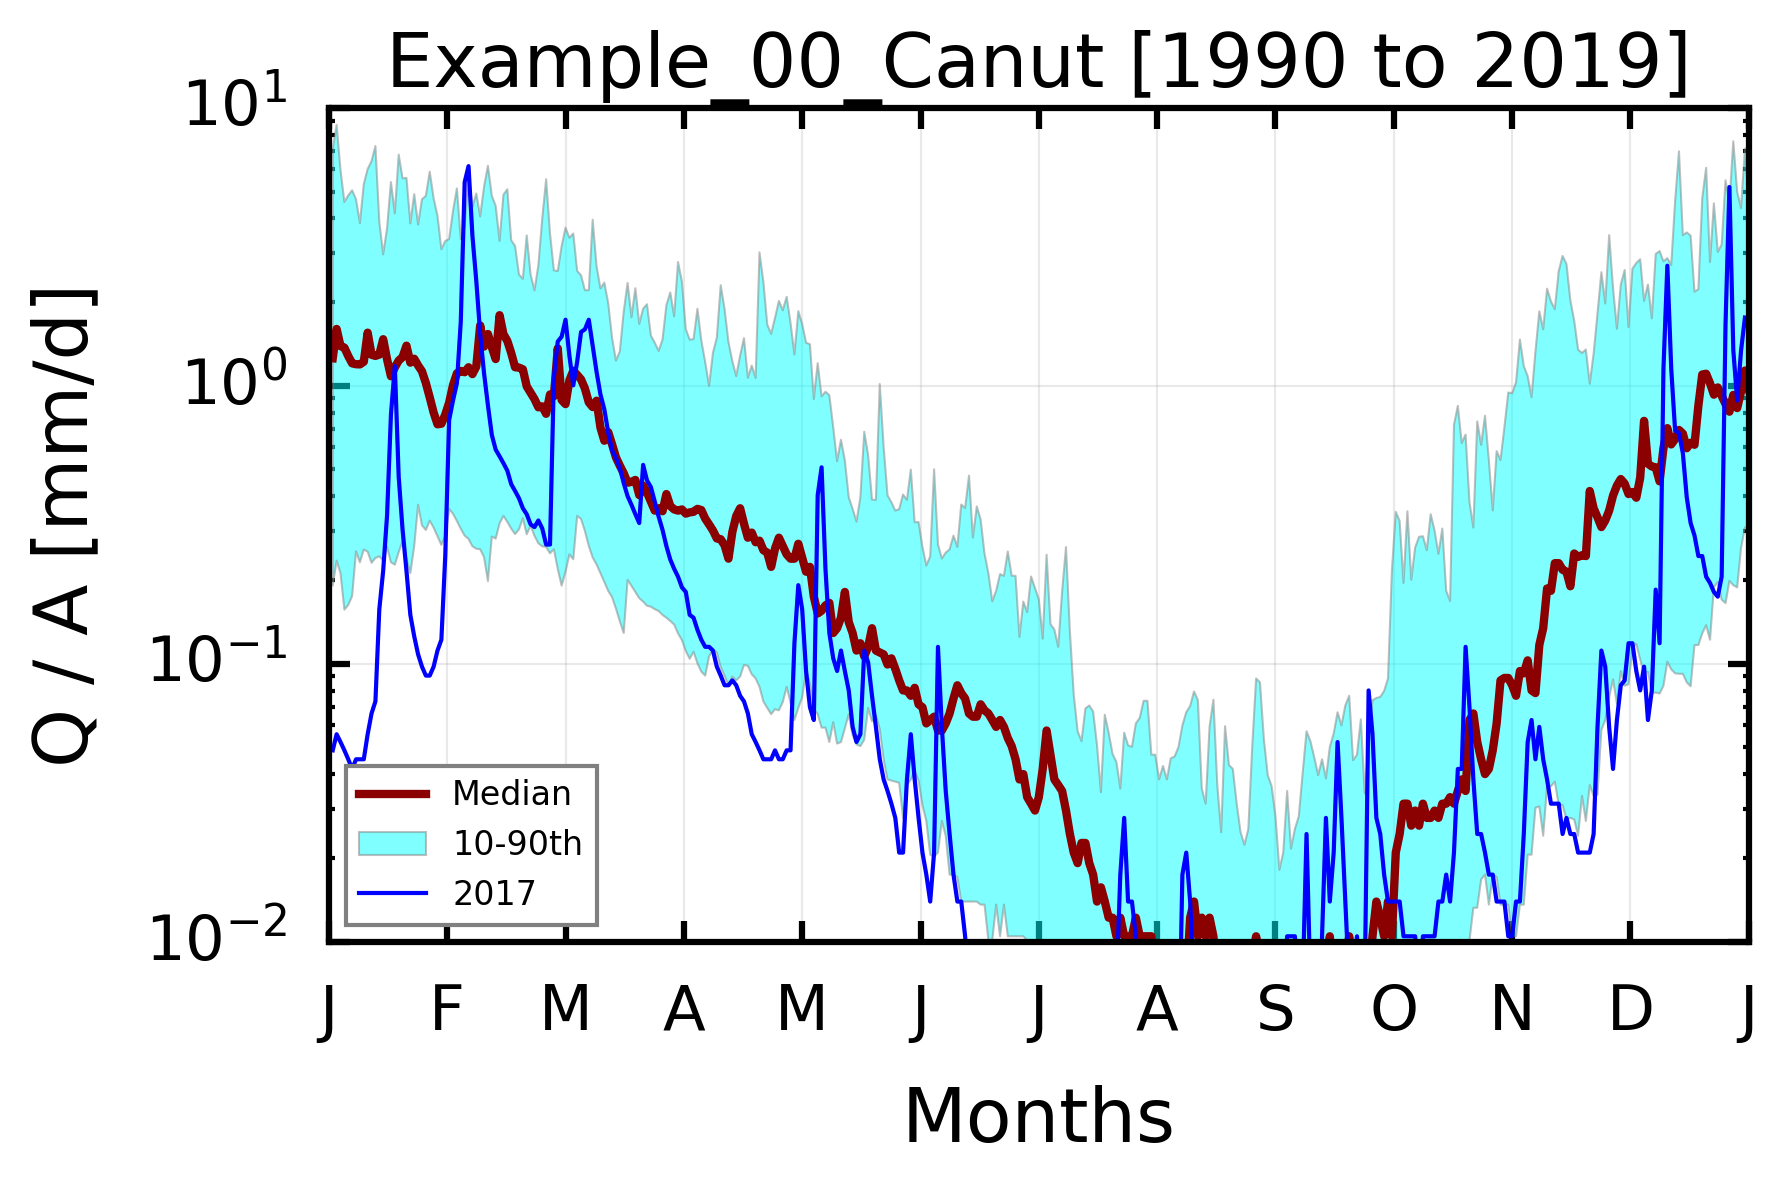

In [9]:
# STREAMFLOW PLOT

Qobs = pd.read_csv(data_path+'/'+'hydrometry catchment Canut.csv', sep=';', index_col=0, parse_dates=True)
Qobs = Qobs.squeeze()
Qobs = Qobs.rename('Q')
def select_period(df, first, last):
    df = df[(df.index.year>=first) & (df.index.year<=last)]
    return df
area = BV.geographic.area
first = 1990
last = 2019
Qobs = select_period(Qobs, first, last)
Qobs = (Qobs / (area*1000000)) * (3600 * 24) * 1000 # m3/s to mm/j
data_index = Qobs.copy()

mean_mensual = data_index.resample('M').mean() # mensual mean
mean_annual = data_index.resample('Y').mean() # annual mean
Mean = round(data_index.mean(),2)
Mean = data_index.mean()
Min = data_index.resample('Y').min()
Q10 = data_index.resample('Y').quantile(0.10)
Q25 = data_index.resample('Y').quantile(0.25)
Q50 = data_index.resample('Y').quantile(0.50)
Q75 = data_index.resample('Y').quantile(0.75)
Q90 = data_index.resample('Y').quantile(0.90)
Max = data_index.resample('Y').max()
mean_interan_days = data_index.groupby([data_index.index.month,data_index.index.day], as_index=True).mean().to_frame()
std_interan_days = data_index.groupby([data_index.index.month,data_index.index.day], as_index=True).std()
q10_interan_days = data_index.groupby([data_index.index.month,data_index.index.day], as_index=True).quantile(0.10)
q90_interan_days = data_index.groupby([data_index.index.month,data_index.index.day], as_index=True).quantile(0.90)
q50_interan_days = data_index.groupby([data_index.index.month,data_index.index.day], as_index=True).quantile(0.50)
mean_interan_days['std'] = std_interan_days
mean_interan_days['q10'] = q10_interan_days
mean_interan_days['q90'] = q90_interan_days
mean_interan_days['q50'] = q50_interan_days
mean_interan_days.index.names = ['months','days']
mean_interan_days = mean_interan_days.reset_index()
mean_interan_days = mean_interan_days.sort_values(['months','days'])
mean_interan_days['counts'] = np.array(range(1,len(mean_interan_days)+1))

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(mean_interan_days.counts, mean_interan_days.q50, lw=2, color='darkred', label='Median')
yerrmax = mean_interan_days.q90
yerrmin = mean_interan_days.q10
ax.fill_between(mean_interan_days.counts, yerrmin, yerrmax, color='cyan', edgecolor='grey', lw=0.5, alpha=0.5, label='10-90th')
ax.set_yscale('log')
ax.set_xlim(0,366)
ax.set_ylim(0.01,10)
ax.tick_params(axis='both', which='major', pad=10)
x1 = np.linspace(0,366,13)
squad = ['J','F','M','A','M','J','J','A','S','O','N','D','J']
ax.set_xticks(x1)
ax.set_xticklabels(squad, minor=False, rotation='horizontal')
ax.set_xlabel('Months', labelpad=+10)
ax.set_ylabel('Q / A [mm/d]',labelpad=+10)
ax.set_title(watershed_name + ' [' + str(first) + ' to ' + str(last) + ']')
ax.grid(alpha=0.25, zorder=0)
one = 2017
dates = np.array([one],dtype=np.int64)
colors = ['blue']
for z in np.array(range(len(dates))):
    onlyone = data_index[(data_index.index.year==dates[z])].to_frame()
    onlyone = onlyone.groupby([onlyone.index.month, onlyone.index.day], as_index=True).mean()
    onlyone['counts'] = np.array(range(1,len(onlyone)+1))
    ax.plot(onlyone.counts, onlyone['Q'], color=colors[z], lw=1, label = str(dates[z]))
ax.legend(loc='lower left')
plt.tight_layout()

In [10]:
#%% ---- MODEL PARAMETRIZATION

# Name of the model/simulation
model_name = 'test_0'

# Import modules
BV.add_settings()
BV.add_climatic()
BV.add_hydraulic()

# Frame settings
BV.settings.update_model_name(model_name) # Name of the model/simulation
BV.settings.update_box_model(True)
BV.settings.update_sink_fill(False)
BV.settings.update_simulation_state('steady') # Transient
BV.settings.update_active_plot(plot_cross=False)
BV.settings.update_split_temporal(split_temp=False)

# Climatic settings
BV.climatic.update_recharge(350 / 1000 / 365, sim_state=BV.settings.sim_state)
BV.climatic.update_first_clim('mean') # or 'first or value

# Hydraulic settings
BV.hydraulic.update_nlay(5)
BV.hydraulic.update_lay_decay(1.5) # 1 if not activated
BV.hydraulic.update_bottom(None) # Set a value to set a flat bottom
BV.hydraulic.update_thick(50) # Not consider if bottom != of None
BV.hydraulic.update_hyd_cond(2e-5 * 24 * 3600) # m/d
BV.hydraulic.update_porosity(1/100) # -
BV.hydraulic.update_cond_decay(1/20) # Exponential decay with depth : 1/10 (about half decrease at 10m)
BV.hydraulic.update_poro_decay(1/20)
BV.hydraulic.update_cond_vertical(None) # or [ [1e-5, [0, 20]], [1e-6, [20,80]] ]
BV.hydraulic.update_cond_drain(None)

# Boundary settings
BV.settings.update_bc_sides(None, None)
BV.add_oceanic('None')

# Particle tracking settings
BV.settings.update_input_particules(zone_partic='domain') # or 'domain'


Init settings module to set model parameter
Init climatic module to set model parameter
Init hydraulic module to set model parameter


In [11]:
#%% ---- GROUNDWATER FLOW MODEL RUN

# Pre-processing
model_modflow = BV.preprocessing_modflow(for_calib=False)

# Processing
success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)

# Post-processing
if success_modflow == True:
    BV.postprocessing_modflow(model_modflow,
                              watertable_elevation=True,
                              watertable_depth=True, 
                              seepage_areas=True,
                              outflow_drain=True,
                              groundwater_flux=True,
                              groundwater_storage=True,
                              accumulation_flux=True,
                              persistency_index=False, # only in transient
                              intermittency_monthly=False, # only in transient
                              intermittency_weekly=False, # only in transient
                              intermittency_daily=False, # only in transient
                              export_all_tif=False)


FloPy is using the following executable to run the model: /home/agauvain/Git/HydroModPy/bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: test_0.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2024/09/12 11:50:46

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2024/09/12 11:50:47
 Elapsed run time:  1.074 Seconds

  Normal termination of simulation
    Time:  0


In [12]:
#%% ---- PARTICLE TRACKING RUN

# Pre-processing
if success_modflow == True:
    model_modpath = BV.preprocessing_modpath(model_modflow)

# Processing
    success_modpath = BV.processing_modpath(model_modpath, write_model=True, run_model=True)

# Post-processing
if success_modpath == True:
    BV.postprocessing_modpath(model_modpath,
                              ending_point=True,
                              starting_point=True,
                              pathlines_shp=True,
                              particules_shp=False,
                              random_id=None) # None


writing loc particle data
writing loc particle data
FloPy is using the following executable to run the model: /home/agauvain/Git/HydroModPy/bin/linux/mp6
Processing basic data ...
Checking head file ...
Checking budget file and building index ...
 
Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00                                                                       
Particle tracking complete. Writing endpoint file ...                                                                               
End of MODPATH simulation. Normal termination.
wrote /home/agauvain/Git/HydroModPy/examples/results/Example_00_Canut/results_simulations/test_0/_postprocess/_particules/ending.shp
wrote /home/agauvain/Git/HydroModPy/examples/results/Example_00_Canut/results_simulations/test_0/_postprocess/_particules/starting.shp
(numpy.record, {'names': ['x', 'y', 'z', 'time', 'k', 'particleid'], 'formats': ['<f4', '<f4', '<f4', '<f4', '<i4', '<i4'], 'offsets'

In [13]:
#%% ---- GENERATE TIMESERIES

timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=model_modpath,
                                                  actual_date=True, 
                                                  subbasin_results=True,
                                                  freq_time='D') # or 'M' or None



Extract modflow and modpath results in timeseries
Subbasin zones
Subbasin zones
Subbasin zones


In [14]:
#%% ---- GENERATE NETCDF FILES

netcdf_results = BV.postprocessing_netcdf(model_modflow,
                                          actual_date=True)

Extract modflow results in netcdf


Init climatic module to set model parameter


Text(0.5, 1.0, 'Recharge [mm/d]')

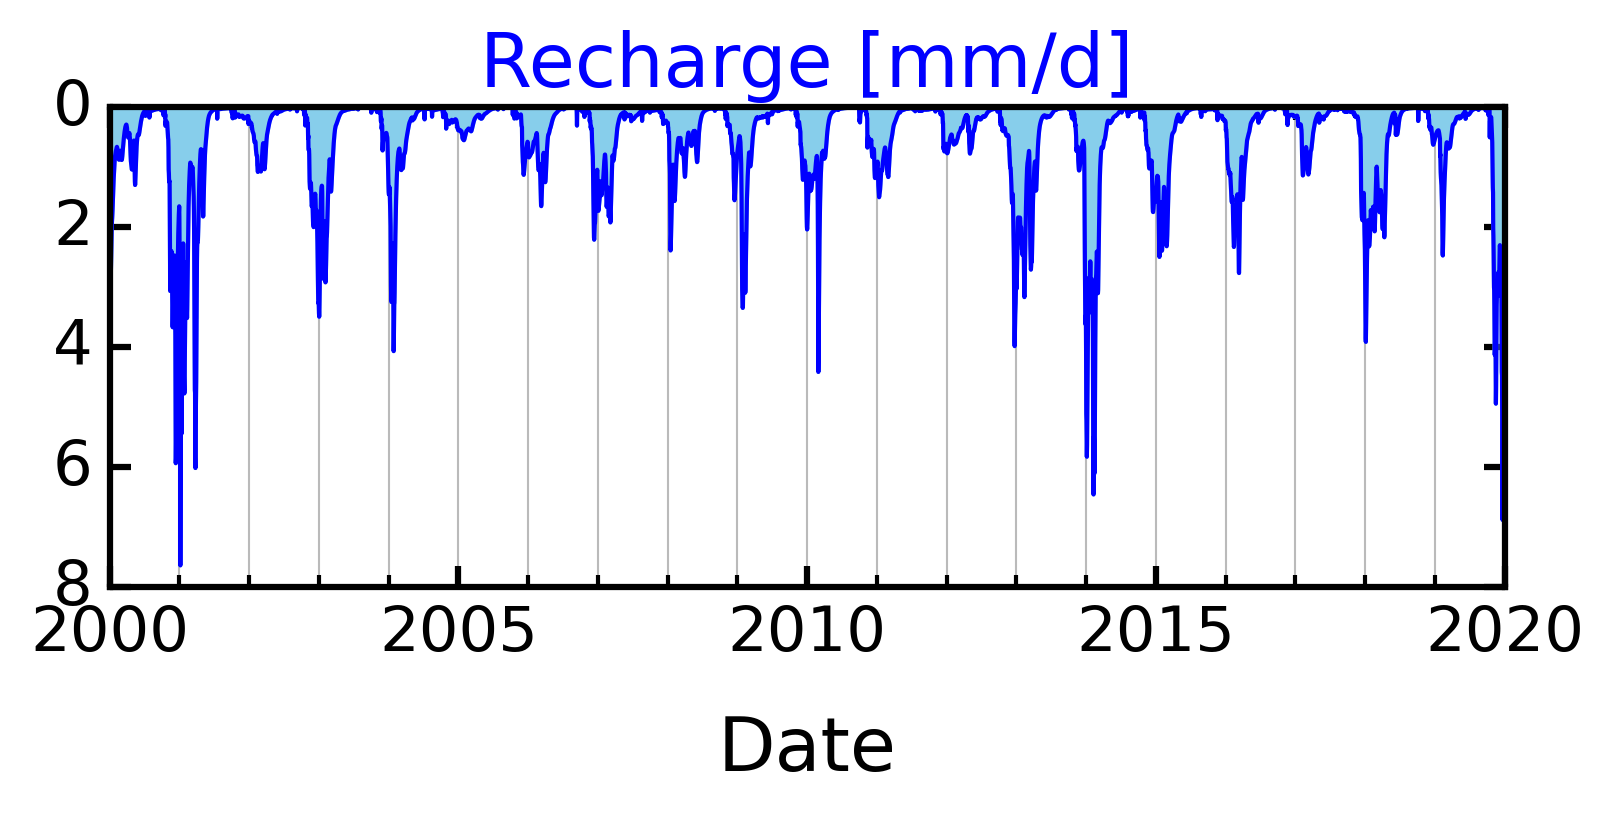

In [15]:
#%% ---- PLOT RESULTS

#%% RECHARGE INPUT

BV.add_climatic()
BV.climatic.update_recharge_reanalysis(path_file=os.path.join(data_path,'_climate_REANALYSIS.csv'),
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')

fig, ax = plt.subplots(1,1, figsize=(6,2), dpi=300)
ax.patch.set_visible(False)
# axb = ax.twinx()
R = BV.climatic.recharge
ax.plot(R.index, R,  color='blue', lw=1, ms=0, clip_on=True)
# axb.bar(R.resample('Y').sum().index, R.resample('Y').sum(),  color='red', lw=0, width=100, alpha=1, clip_on=True)
# axb.set_ylim(0,1000)
# axb.invert_yaxis()
ax.fill_between(R.index, R*0, R, color='skyblue', clip_on=True, alpha=1)
ax.set_xlabel('Date')
# ax.set_ylabel('Recharge [mm/d]', color='blue')
ax.xaxis.set(minor_locator=mdates.YearLocator(1), major_locator=mdates.YearLocator(5))
ax.set_ylim(0,8)
ax.set_xlim(pd.to_datetime('2000'), pd.to_datetime('2020'))
ax.set_yticks([0,2,4,6,8])
ax.grid(which='both', axis='x')
# ax.set_zorder(axb.get_zorder() + 1)
# plt.setp(axb.get_yticklabels(), color="red")
ax.invert_yaxis()
ax.set_title('Recharge [mm/d]', color='blue')

# fig.savefig(out_path+'/'+watershed_name+'/results_simulations/'+model_name+'/_postprocess/_figures/'+'input_rec.png', dpi=300, bbox_inches='tight')


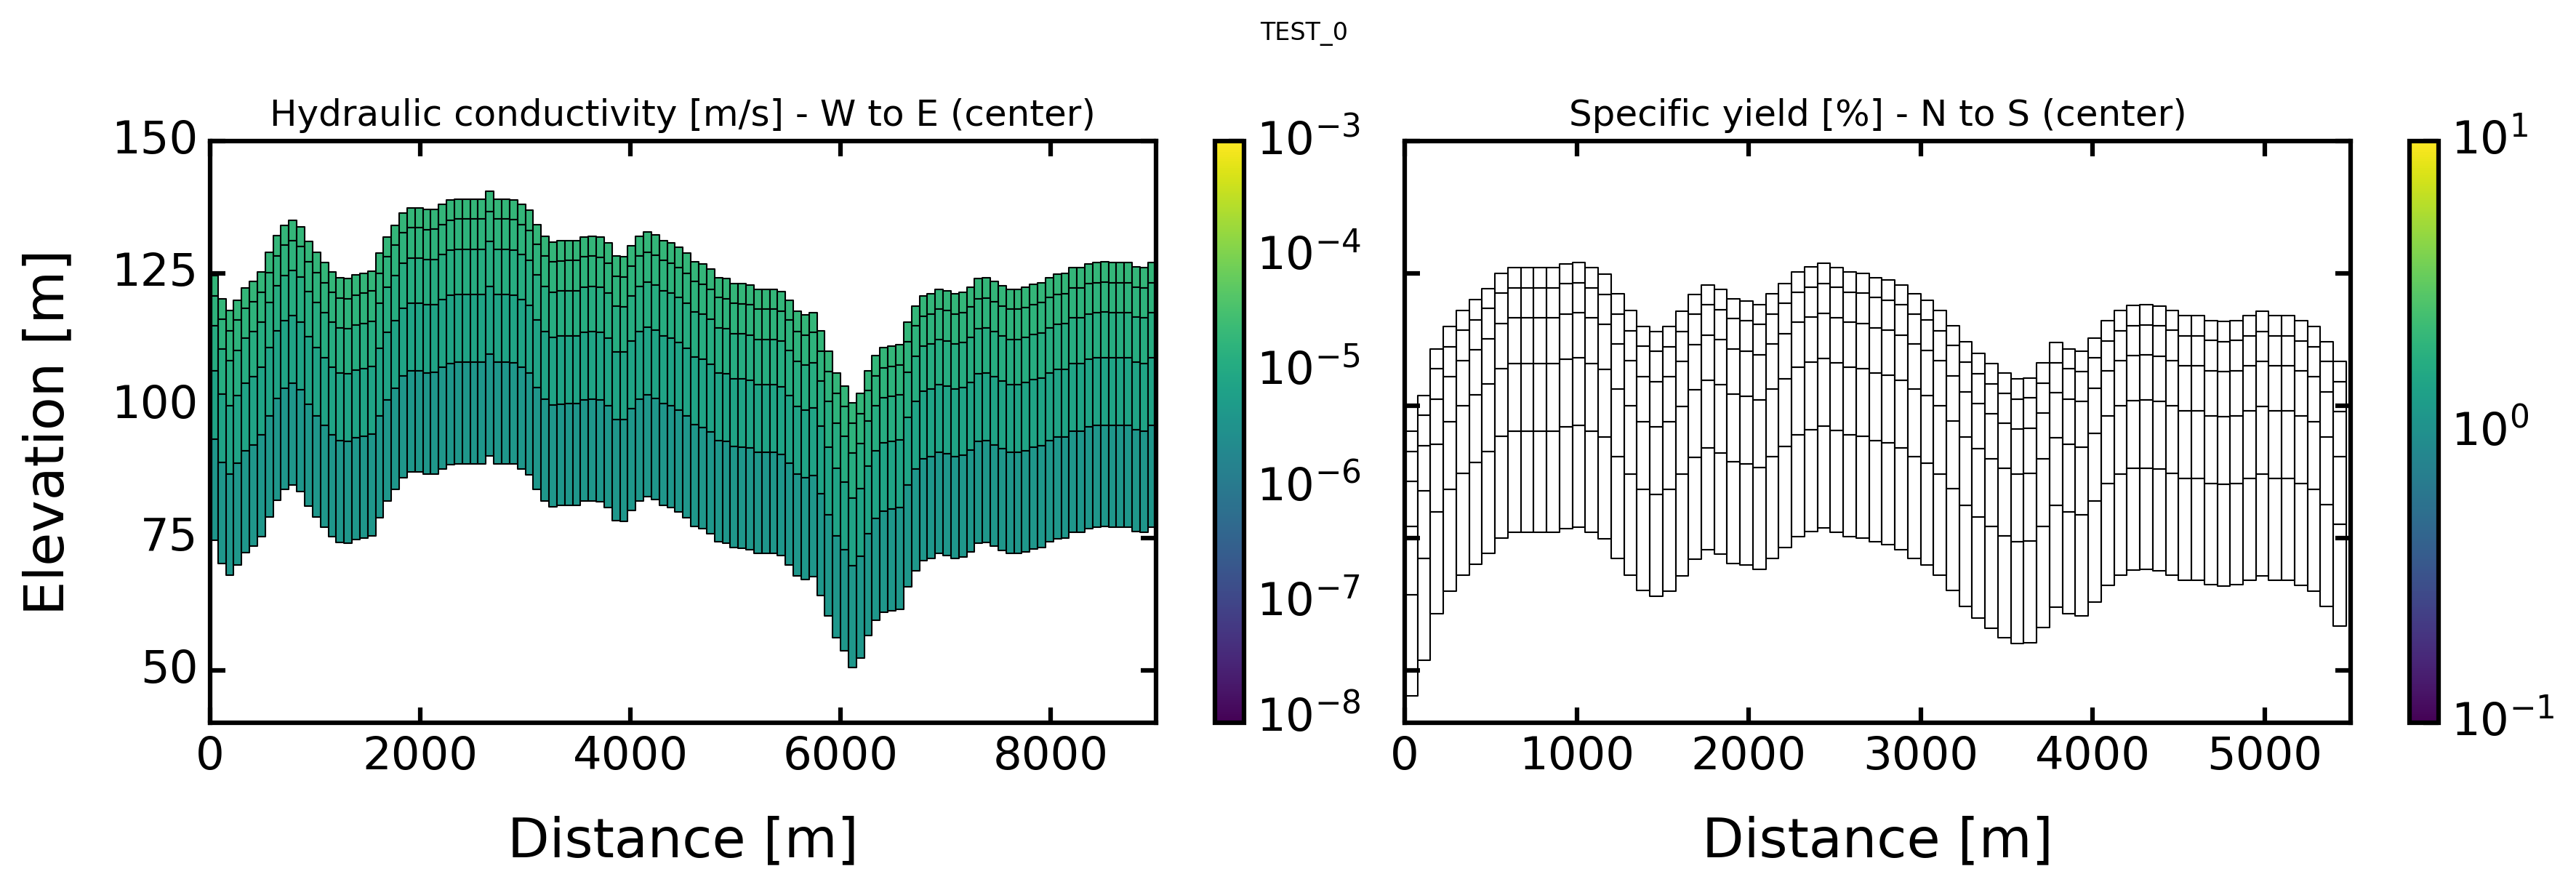

In [16]:
#%% MESH DISCRETIZATION

mf = flopy.modflow.Modflow.load(simulations_folder+'/'+model_name+'/'+model_name+'.nam')
gridname = simulations_folder+model_name+'/'+model_name+'.dis'
grid_model = mf.modelgrid
hk_grid = mf.upw.hk
sy_grid = mf.upw.sy

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axs = axs.ravel()

ax = axs[0]
modelxsect = flopy.plot.PlotCrossSection(model=mf, line={'Row': int((grid_model.shape[1])/2)})
val = hk_grid.array/24/3600 # m/s
try:
    for i in range(val.shape[0]):
        val[i][val[i] <= np.nanmin(val[i])] = np.nanmin(val[i][np.nonzero(val[i])])
except:
    pass
cb = modelxsect.plot_array(val, ax=ax, cmap='viridis', lw=0.5, norm=mpl.colors.LogNorm(vmin=1e-3,vmax=1e-8))
ax.set_title('Hydraulic conductivity [m/s] - W to E (center)', fontsize=12)
ax.set_xlim(0, 9000)
ax.set_ylim(40, 150)
ax.set_xticks([0,2000,4000,6000,8000])
ax.set_yticks([50,75,100,125,150])
ax.set_xlabel('Distance [m]')
ax.set_ylabel('Elevation [m]')
fig.suptitle(model_name.upper(), x=0.22, y=1.05, fontsize=8)
fig.colorbar(cb)
plt.tight_layout()

ax = axs[1]
modelxsect = flopy.plot.PlotCrossSection(model=mf, line={'Column': int((grid_model.shape[2])/2)})
cb = modelxsect.plot_array(sy_grid.array*100, ax=ax, cmap='viridis', lw=0.5,
                            # vmin=0, vmax=30,
                            norm=mpl.colors.LogNorm(vmin=0.1, 
                                                    vmax=10))
ax.set_title('Specific yield [%] - N to S (center)', fontsize=12)
ax.set_xlim(0, 5500)
ax.set_ylim(40, 150)
ax.set_xticks([0,1000,2000,3000,4000,5000])
ax.set_yticks([50,75,100,125,150])
ax.set_xlabel('Distance [m]')
fig.suptitle(model_name.upper(), x=0.5, y=1.0, fontsize=8)
fig.colorbar(cb)
plt.tight_layout()

# fig.savefig(out_path+'/'+watershed_name+'/results_simulations/'+model_name+'/_postprocess/_figures/'+'mesh_cross.png', dpi=300, bbox_inches='tight')


/home/agauvain/Git/HydroModPy/examples/results/Example_00_Canut/results_stable


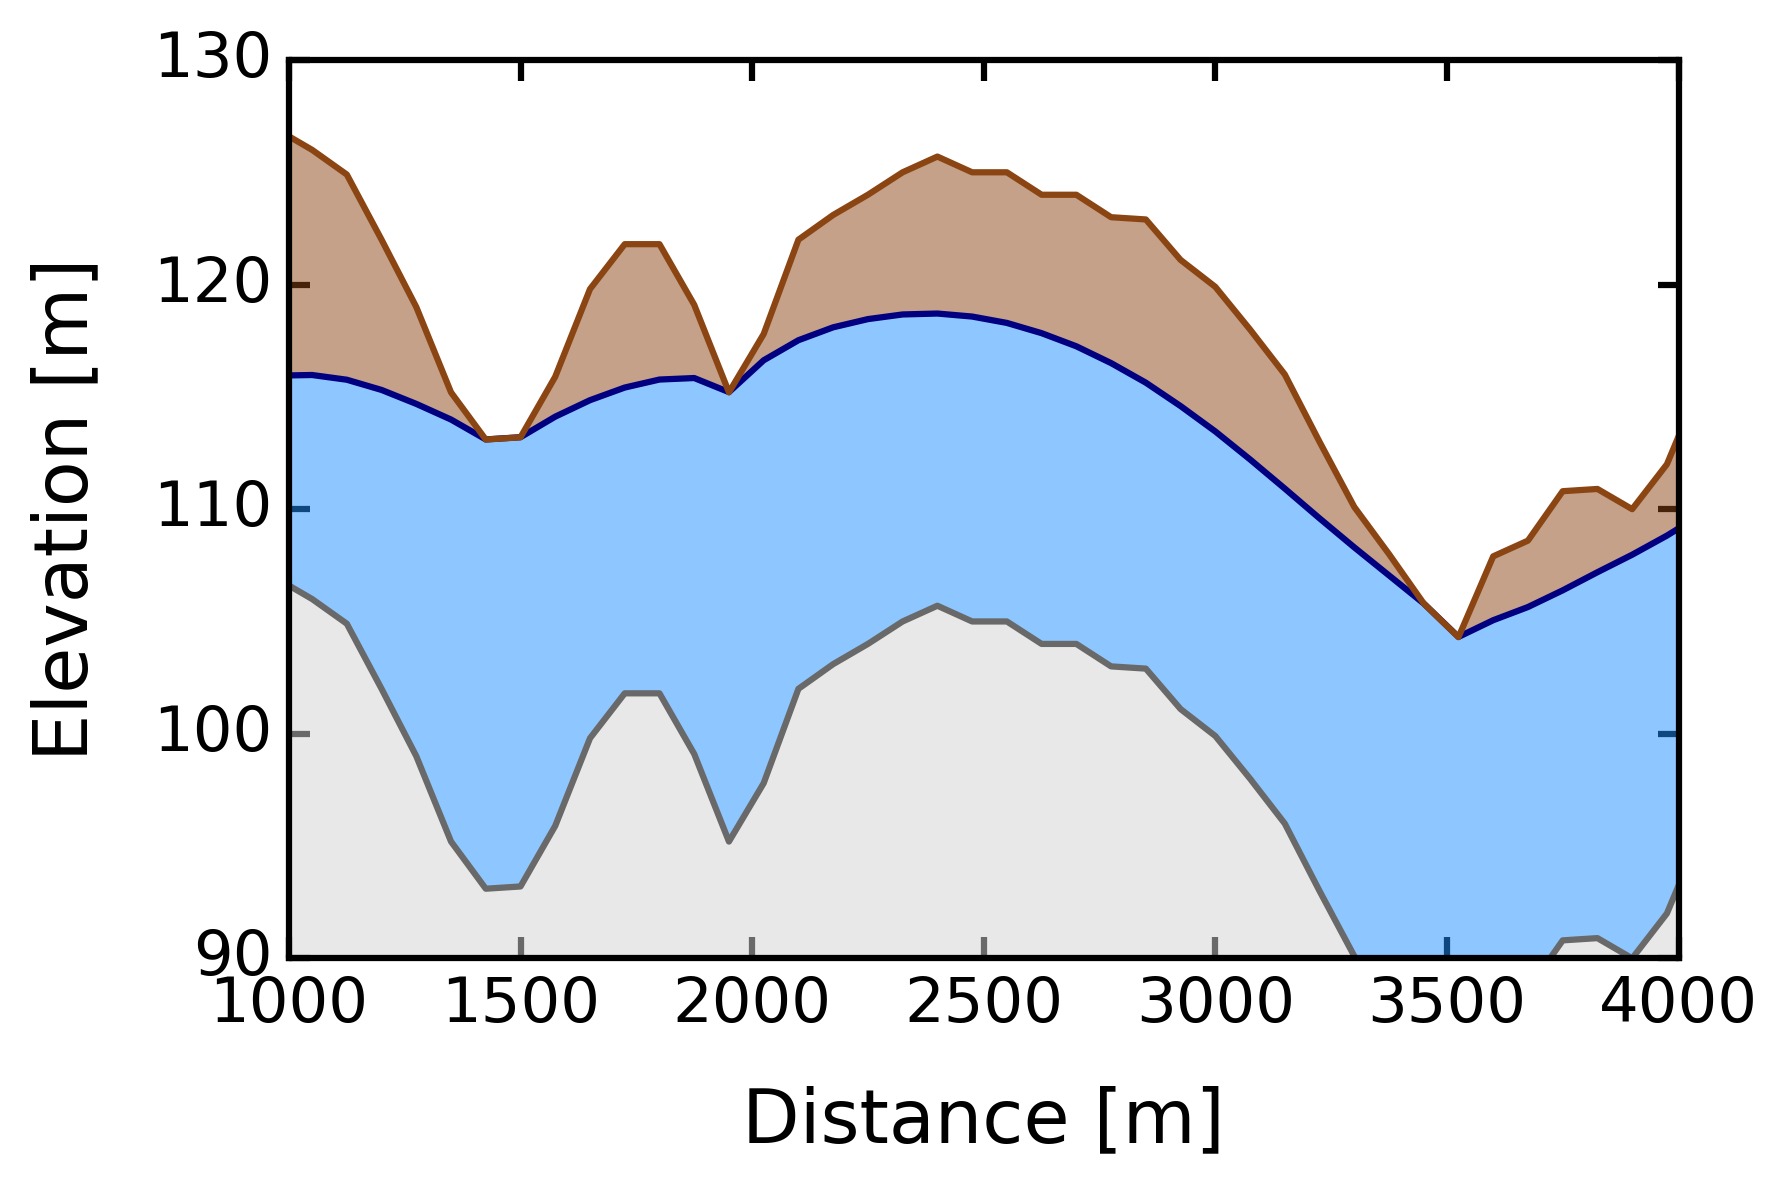

In [17]:
#%% FIXED CROSS-SECTION

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)
print(stable_folder)

mask = imageio.imread(stable_folder+'/geographic/'+'watershed_dem.tif')
watertable_elevation = np.load(simulations_folder+'/'+model_name+'/_postprocess/'+'watertable_elevation'+'.npy', allow_pickle=True).item()

dem_data = imageio.imread(BV.geographic.watershed_dem)
wt_data = watertable_elevation[0]

xvalues = np.linspace(-1,1,dem_data.shape[1])
yvalues = np.linspace(-1,1,dem_data.shape[0])
xx, yy = np.meshgrid(xvalues,yvalues)

cur_x = dem_data.shape[1] /2
cur_x = 65

wt_prof = wt_data.astype(float)
wt_prof[wt_prof<0] = np.nan
dem_max = dem_data.max()
dem_prof = dem_data.astype(float)
dem_prof[dem_prof<0] = np.nan
dem_plot = np.ma.masked_array(dem_data, mask=(dem_data<0))
dem_v_plot = dem_prof[:,int(cur_x)]
dem_v_plot[dem_v_plot == 0] = np.nan
wt_v_plot = wt_prof[:,int(cur_x)]
wt_v_plot[wt_v_plot == 0] = np.nan
           
wt_v_fill = ax.fill_between(np.arange(xx.shape[0])*75, dem_v_plot-20, wt_v_plot, color='dodgerblue', alpha=0.5, lw=0)
w_prof = ax.plot(np.arange(xx.shape[0])*75, wt_v_plot, color='navy', lw=1.5)
wt_v_fill = ax.fill_between(np.arange(xx.shape[0])*75, wt_v_plot, dem_v_plot, color='saddlebrown', alpha=0.5, lw=0)
d_prof = ax.plot(np.arange(xx.shape[0])*75, dem_v_plot, 'saddlebrown', lw=1.5)
ax.fill_between(np.arange(xx.shape[0])*75, 0, dem_v_plot-20, color='lightgrey', alpha=0.5, lw=0)
ax.plot(np.arange(xx.shape[0])*75, dem_v_plot-20, color='dimgray', lw=1.5)

ax.set_xlim(1000, 4000)
ax.set_ylim(90, 130)
ax.set_yticks([90,100,110,120,130])
ax.set_xlabel('Distance [m]')
ax.set_ylabel('Elevation [m]')

plt.tight_layout()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

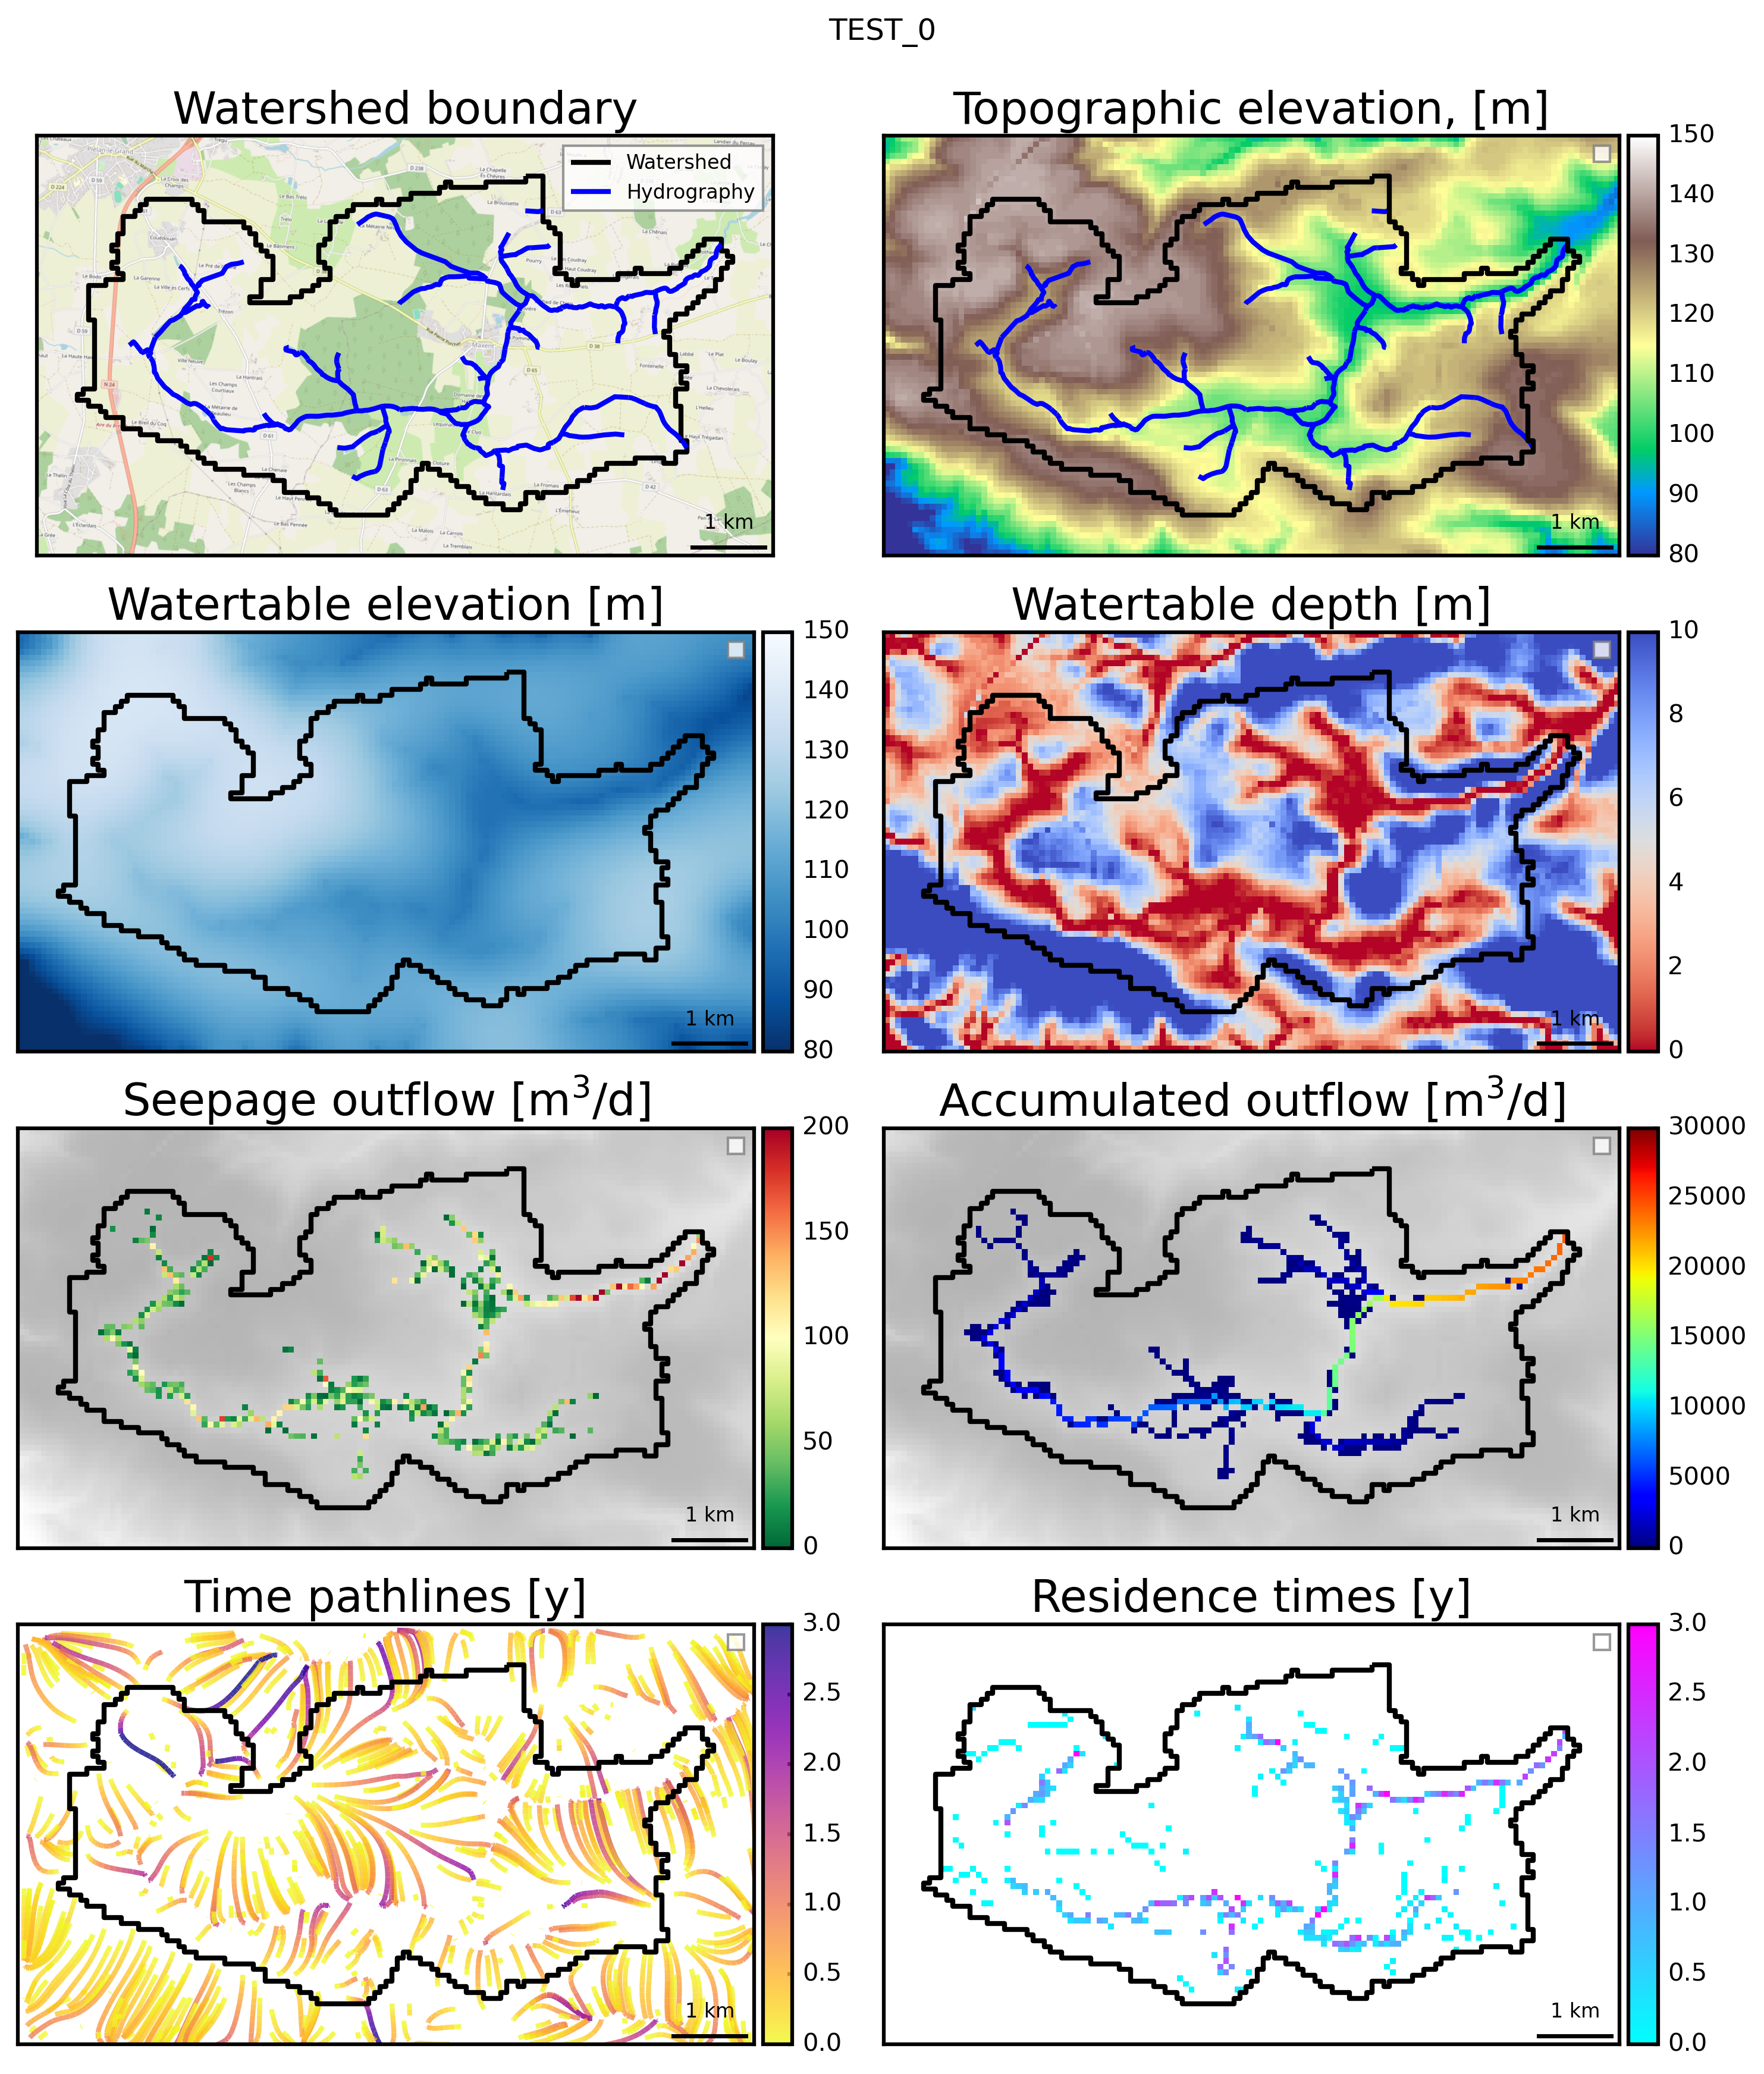

In [19]:

#%% 2D VISUALIZATION

visu = visualization_results.Visualization(BV, model_name)
visu.visual2D(object_list = [
                             'map',
                             'grid',
                             'watertable',
                             'watertable_depth',
                             'drain_flow',
                             'surface_flow',
                             'pathlines',
                             'residence_times'
                             ],
              color_scale = [
                             (None,None),
                             (80,150),
                             (80,150),
                             (0,10),
                             (0,200),
                             (0,30000),
                             (0,3),
                             (0,3),
                             ], 
                             lines=750)




In [20]:
#%% 3D VISUALIZATION

export_vtuvtk.VTK(BV, model_name)
visu = visualization_results.Visualization(BV, model_name)
visu.visual3D(interactive=True, object_list=[
                                             'grid',
                                             'watertable',
                                             'watertable_depth',
                                             'surface_flow',
                                             'drain_flow',
                                             'pathlines'
                                             ],
                                               view='south-west',
                                              # view='north',
                                              lines=None,
                                              cloc=(0.7,0.1),
                                              z_scale=10)


Export vtuvtk grid
Export vtuvtk watertable
Export vtuvtk boundary
Export vtuvtk pathlines
Export vtuvtk streams


[vedo.file_io] ERROR: in load(), cannot load /home/agauvain/Git/HydroModPy/examples/results/Example_00_Canut/results_simulations/test_0/_postprocess/_vtuvtk/streams.vtk


         mesh.points() -> mesh.vertices
         (silence this with vedo.core.warnings['points_getter']=False)
grid
watertable
watertable_depth
surface_flow
drain_flow
pathlines


In [21]:
#%% INTERACTIVE CROSS-SECTION

dem_data = imageio.imread(os.path.join(stable_folder,'geographic','watershed_box_buff_dem.tif')) # dem data
stream_data = imageio.imread(os.path.join(stable_folder,'hydrography','regional stream network.tif')) # river data
watertable_data = imageio.imread(os.path.join(simulations_folder,model_name,'_postprocess/_rasters/','watertable_elevation_t(0).tif')) # watertable data
interactive = True
visu = visualization_results.Visualization(BV, model_name)
visu.interactive_cross_section(dem_data, watertable_data, stream_data, interactive)